# 2.2 — DPI-Flow

**Папка 2, подноутбук 2.** Grid search по гиперпараметрам DPI-Flow с богатой историей по
всем метрикам и **выбором метрики отбора** → сохранение лучших в
`models/dpi_flow/hyperparams.json` → финальное обучение чтением JSON с отслеживанием метрик.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
from liquefaction_ai import resolve_device, configure_performance, describe_device
device = configure_performance(resolve_device())
print("device:", describe_device(device))
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import DPIFlow
from liquefaction_ai.evaluation import collect_outputs

device: mps (Apple Metal)
device: mps | dims static/prefix/seq: 38 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Censored mean absolute error of the predicted ...
5,N_liq_Curve_Coherence_MAE,N_liq/curve coherence MAE,cycles,lower is better,Mean absolute gap between the reported N_liq a...
6,Risk_Curve_Coherence_Rate,Risk/curve coherence rate,–,higher is better,Fraction of samples for which risk>=0.5 agrees...
7,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
8,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
9,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...


## Шаг 1. Grid search и сохранение гиперпараметров

Selection metric: Traj_RMSE_continuation | best: {'hidden_dim': 128, 'use_traj_residual': True}


,hidden_dim,use_traj_residual,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,Supports_Censored_Nliq,N_liq_logMAE_liq,...,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,CRR_Onset_Coherence_MAE,Traj_RMSE_continuation_siteMacro,N_liq_logMAE_siteMacro,N_sites_test
0,128,True,-0.3104,609.3911,1284.4229,0.7105,1.3023,118.0,1.0,0.9525,...,-0.8356,0.0580,0.1898,70.0,1.0,1.0,0.1047,0.0906,0.7175,2.0
1,128,False,-0.6596,726.0898,1411.2299,0.8098,1.4324,118.0,1.0,1.0906,...,-0.8313,0.0583,0.2016,70.0,1.0,1.0,0.1056,0.0920,0.8109,2.0
2,192,False,-0.4847,447.4968,1080.1896,0.5599,1.0638,118.0,1.0,0.7478,...,-0.7061,0.0634,0.2120,70.0,1.0,1.0,0.1230,0.0964,0.5758,2.0
3,192,True,-0.5629,471.8942,1111.4408,0.5791,1.0981,118.0,1.0,0.7730,...,-0.7102,0.0633,0.2009,70.0,1.0,1.0,0.1181,0.0969,0.5848,2.0
4,160,False,-0.2129,1159.7369,1793.8966,1.2861,1.8392,118.0,1.0,1.7510,...,-0.7088,0.0646,0.1937,70.0,1.0,1.0,0.0849,0.1048,1.2227,2.0
5,160,True,-0.2403,951.3920,1613.3126,1.0908,1.6481,118.0,1.0,1.4821,...,-0.6944,0.0663,0.1758,70.0,1.0,1.0,0.0850,0.1090,1.0473,2.0


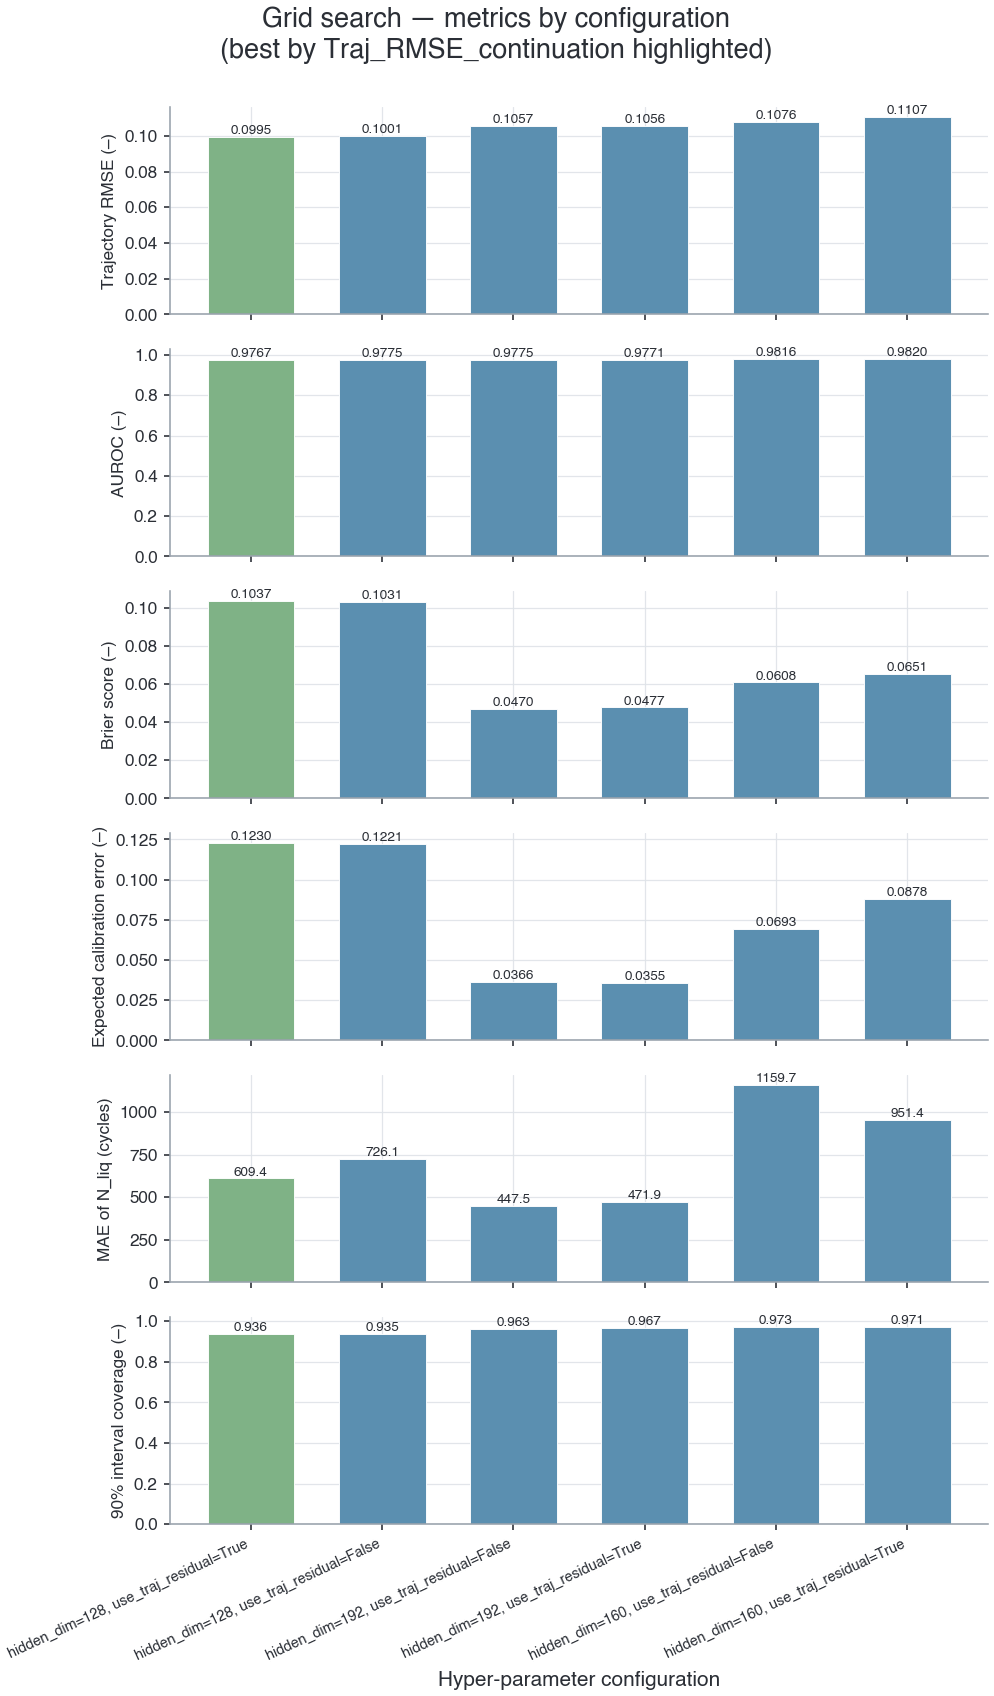

In [3]:
# >>> Метрика, по которой grid search выбирает лучшие гиперпараметры <<<
SELECTION_METRIC = "Traj_RMSE_continuation"   # например: "Traj_RMSE", "Brier", "AUROC", "N_liq_MAE", "val_loss"
DASHBOARD_METRICS = ["Traj_RMSE", "AUROC", "Brier", "ECE", "N_liq_MAE", "Coverage_90"]

# MC-микстура (#3): обучать предиктив как смесь по θ∼flow (mixture-NLL + energy-CRPS) — это
# калибрует разброс flow под предиктивную ошибку (NLL/CRPS/coverage). MC_SOTA=False → прежнее
# поведение (одиночный gaussian_nll). Для SOTA-эксперимента включи MC_SOTA=True.
MC_SOTA = False
_mc = dict(mc_train_samples=4, mc_crps_weight=0.3) if MC_SOTA else dict()
fixed = dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len,
             prefix_len=config.prefix_len, max_cycle_reference=config.max_cycle_reference,
             theta_dim=31, probabilistic=True, use_analytical_layer=True, use_flow=True,
             liq_threshold=config.liq_threshold, calibration_steps=0,
             traj_residual_span=0.10, use_free_increment=False, kl_weight=0.02, **_mc)
# Разнообразный грид: ёмкость энкодера × глубина/шаг дифф-калибровки θ × residual поверх ODE.
# HEADLINE flow: calibration_steps=0 → честная нормированная плотность потока (mixture-NLL валиден).
# Эвристическая θ-доводка (1/2 шага) вынесена в АБЛЯЦИИ (ablation_study: calib_steps_1/2), т.к.
# её якобиан не входит в плотность потока. Грид варьирует ёмкость и residual поверх ODE.
grid = {"hidden_dim": [128, 160, 192],
        "use_traj_residual": [True, False]}
res, best = grid_search(lambda p: DPIFlow(**fixed, **p), grid, gs_train, gs_val,
                        config, device, search_epochs=config.grid_search_epochs, score_metric=SELECTION_METRIC)
print("Selection metric:", SELECTION_METRIC, "| best:", best)
display(english_metric_table(res).round(4))
write_hyperparams(MODELS_DIR, "dpi_flow", {"model_type": "DPIFlow", "display_name": "DPI-Flow",
                  "model_kwargs": {**fixed, **best},
                  "search": {"grid": grid, "score_metric": SELECTION_METRIC, "best": best}})
show_grid_dashboard(res, grid, SELECTION_METRIC, DASHBOARD_METRICS, "2_2_grid_search").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
from liquefaction_ai.evaluation import compute_metrics, fit_interval_scale
hp = read_hyperparams(MODELS_DIR, "dpi_flow")
# Best-of-seeds: модель чувствительна к инициализации — выбираем лучшую по ВАЛИДАЦИИ (без утечки теста)
best_model, best_history, best_val = None, None, float("inf")
for seed in [0, 1, 2]:
    torch.manual_seed(seed)
    cand = DPIFlow(**hp["model_kwargs"]).to(device)
    cand, hist = train_model(cand, benchmark["train"], benchmark["val"], epochs=config.publication_physics_epochs,
                             model_name=f"DPI-Flow (seed {seed})", config=config, device=device,
                             track_metrics=True, scheduler="cosine")
    vr, _ = compute_metrics("val", collect_outputs(cand, benchmark["val"], config, device), benchmark["val"], config)
    print(f"seed {seed}: val Traj_RMSE = {vr['Traj_RMSE']:.4f}")
    if vr["Traj_RMSE"] < best_val:
        best_val, best_model, best_history = vr["Traj_RMSE"], cand, hist
model, history = best_model, best_history
# Пост-hoc конформная калибровка интервалов на валидации
calib_scale = fit_interval_scale(model, benchmark["val"], config, device, level=0.90)
save_trained_model(model, MODELS_DIR, "dpi_flow", {**hp, "epochs": len(history),
                   "learning_rate": config.learning_rate, "weight_decay": config.weight_decay,
                   "batch_size": config.batch_size, "calib_scale": calib_scale}, history)
print("saved:", MODELS_DIR / "dpi_flow", "| best val RMSE:", round(best_val, 4), "| var-scale s: (post-hoc σ variance-scaling, NOT conformal)", round(calib_scale, 2))

[DPI-Flow (seed 0)] эпоха 01 | обучение=2.0536 | валидация=-0.3328 | val_AUROC=0.764 | val_RMSE=0.2093 | stale=0/25
[DPI-Flow (seed 0)] эпоха 02 | обучение=-0.1340 | валидация=-0.8106 | val_AUROC=0.952 | val_RMSE=0.1559 | stale=0/25
[DPI-Flow (seed 0)] эпоха 03 | обучение=-0.7552 | валидация=-1.0914 | val_AUROC=0.953 | val_RMSE=0.1319 | stale=0/25
[DPI-Flow (seed 0)] эпоха 04 | обучение=-1.1547 | валидация=-1.2173 | val_AUROC=0.960 | val_RMSE=0.1257 | stale=0/25
[DPI-Flow (seed 0)] эпоха 05 | обучение=-1.3054 | валидация=-1.3580 | val_AUROC=0.957 | val_RMSE=0.1102 | stale=0/25
[DPI-Flow (seed 0)] эпоха 06 | обучение=-1.4722 | валидация=-1.4530 | val_AUROC=0.957 | val_RMSE=0.1012 | stale=0/25
[DPI-Flow (seed 0)] эпоха 07 | обучение=-1.5882 | валидация=-1.3721 | val_AUROC=0.957 | val_RMSE=0.1028 | stale=1/25
[DPI-Flow (seed 0)] эпоха 08 | обучение=-1.7091 | валидация=-1.2785 | val_AUROC=0.958 | val_RMSE=0.1122 | stale=2/25
[DPI-Flow (seed 0)] эпоха 09 | обучение=-1.8255 | валидация=-1.34

## Кривые обучения с метриками

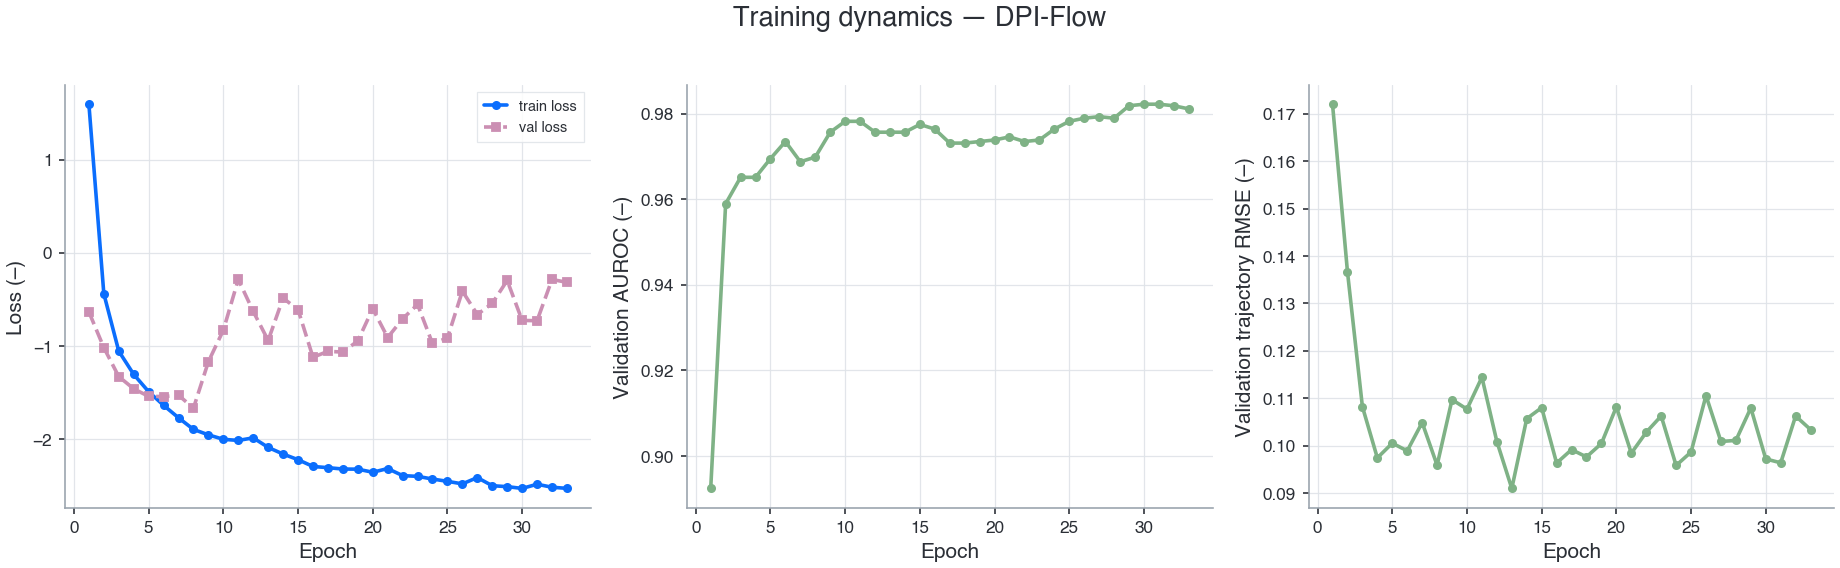

In [5]:
training_dashboard(history, title="Training dynamics — DPI-Flow", model_color="#0b6efd",
                   save=SAVE_FIGS, fig_id="2_2_training_dashboard").show()

## Предпросмотр предсказаний

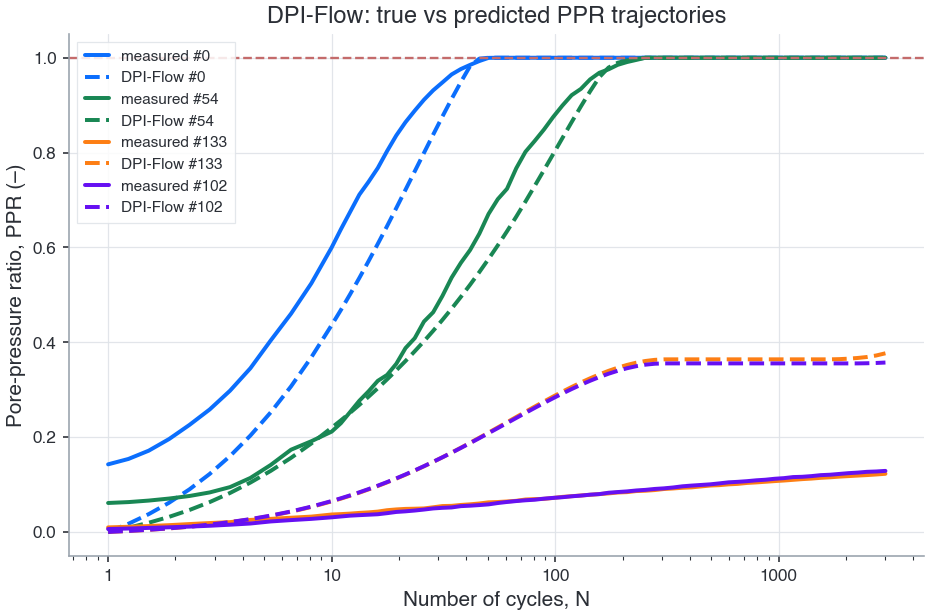

In [6]:
test = benchmark["test"]
outputs = collect_outputs(model, test, config, device)
cycles = test["cycles"].cpu().numpy()
r_true = (test["r_true"] if "r_true" in test else test["r_obs"]).cpu().numpy()  # реальные данные: измеренная кривая
pred = outputs["traj_mean"]
tm = test["meta"].reset_index(drop=True)
pick = tm.sort_values("PPR_max_true", ascending=False).head(2).index.tolist() + tm.sort_values("PPR_max_true").head(2).index.tolist()
series = []
for k, idx in enumerate(pick):
    col = ["#0b6efd", "#198754", "#fd7e14", "#6610f2"][k]
    series.append({"x": cycles[idx], "y": r_true[idx], "name": f"measured #{idx}", "color": col})
    series.append({"x": cycles[idx], "y": pred[idx], "name": f"DPI-Flow #{idx}", "color": col, "dash": "dash"})
lines(series, title="DPI-Flow: true vs predicted PPR trajectories", xlabel="Number of cycles, N",
      ylabel="Pore-pressure ratio, PPR (–)", logx=True, hline=1.0,
      save=SAVE_FIGS, fig_id="2_2_prediction_preview").show()

## Итог

DPI-Flow подобрана grid search (выбор метрики), обучена и сохранена. Дальше — **2.3 EVT-NeuralSSM**.